# Aula 2 — Revisão de Álgebra Linear I
### Matrizes, vetores, multiplicação, transposta, inversa, posto, espaço coluna e espaço nulo

**Professor:** Prof. Dr. Rodrigo Figueiredo Abdo (Instituto Federal de Brasília)

*Curso: Fundamentos de Aprendizado de Máquina Científico para Mecânica dos Fluidos*

## Descrição

Este notebook **complementa** as notas da Aula 2 — não substitui a teoria. A ideia é *ver
funcionando* os objetos da álgebra linear que serão a gramática do curso: combinações lineares,
as visões da multiplicação, a transposta, a inversa, o espaço coluna, o espaço nulo e o posto.

Os exemplos numéricos reproduzem os exemplos das notas, então você pode conferir o resultado do
código contra a conta feita à mão. Onde ajuda, há uma visualização em $\mathbb{R}^2$ ou
$\mathbb{R}^3$.

> Sugestão: rode célula a célula logo após a aula e refaça as contas no papel para os exemplos
> pequenos.

## Requisitos

| Biblioteca | Versão mínima | Finalidade |
|---|---|---|
| `numpy` | 1.22 | vetores, matrizes, posto, produtos |
| `matplotlib` | 3.5 | visualizações em 2D/3D |

Instalação (se necessário):

```bash
pip install numpy matplotlib
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Objetivos

1. Operar vetores e **combinações lineares** e visualizar o *span*.
2. Testar **independência linear** via posto e ver as **três visões** da multiplicação
   matriz-vetor coincidindo.
3. Enxergar uma matriz como **transformação linear** e $AB$ como **soma de produtos externos de
   posto um**.
4. Verificar a **transposta** ($(AB)^T=B^TA^T$), o **produto interno** e a matriz de Gram
   $A^TA$; resolver um sistema $2\times2$.
5. Calcular **espaço coluna**, **espaço nulo** e **posto**, e confirmar o **teorema do núcleo e
   da imagem** $\operatorname{rank}(A)+\dim(\operatorname{Nul} A)=n$.

## 1. Vetores e combinação linear

Vetores são **colunas** em $\mathbb{R}^n$. Uma combinação linear de $\mathbf{u}$ e $\mathbf{v}$ é
$c\,\mathbf{u}+d\,\mathbf{v}$. Reproduzimos o **Exemplo 1** das notas:

$$\mathbf{u}=\begin{bmatrix}1\\2\\-1\end{bmatrix},\quad
\mathbf{v}=\begin{bmatrix}3\\0\\4\end{bmatrix},\qquad
2\mathbf{u}-\mathbf{v}=\begin{bmatrix}-1\\4\\-6\end{bmatrix}.$$

In [2]:
# Exemplo 1: combinação linear em R^3.
u = np.array([1.0, 2.0, -1.0])
v = np.array([3.0, 0.0, 4.0])

print("u =", u)
print("v =", v)
print("2u - v =", 2 * u - v)   # referência das notas: (-1, 4, -6)

u = [ 1.  2. -1.]
v = [3. 0. 4.]
2u - v = [-1.  4. -6.]


Para *ver* a combinação, ilustramos em $\mathbb{R}^2$: $c\,\mathbf{a}+d\,\mathbf{b}$ é "andar"
$c$ vezes ao longo de $\mathbf{a}$ e $d$ vezes ao longo de $\mathbf{b}$.

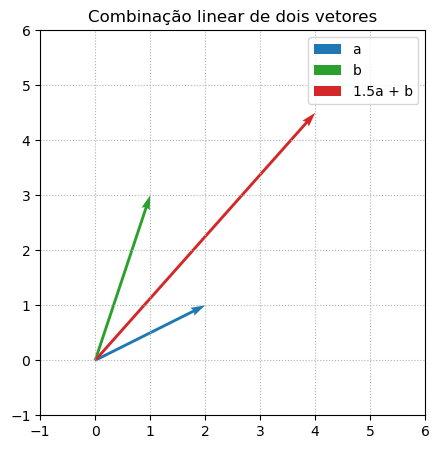

In [3]:
# Combinação linear em R^2: w = 1.5*a + 1.0*b.
a = np.array([2.0, 1.0])
b = np.array([1.0, 3.0])
w = 1.5 * a + 1.0 * b

plt.figure(figsize=(5, 5))
for vec, cor, nome in [(a, "tab:blue", "a"), (b, "tab:green", "b"), (w, "tab:red", "1.5a + b")]:
    plt.quiver(0, 0, *vec, angles="xy", scale_units="xy", scale=1, color=cor, label=nome)
plt.xlim(-1, 6); plt.ylim(-1, 6); plt.gca().set_aspect("equal")
plt.grid(True, ls=":"); plt.legend(); plt.title("Combinação linear de dois vetores")
plt.show()

## 2. Span (espaço gerado)

O *span* é o conjunto de **todas** as combinações lineares. Em $\mathbb{R}^3$: o span de **um**
vetor não nulo é uma **reta**; o de **dois** vetores independentes é um **plano**.

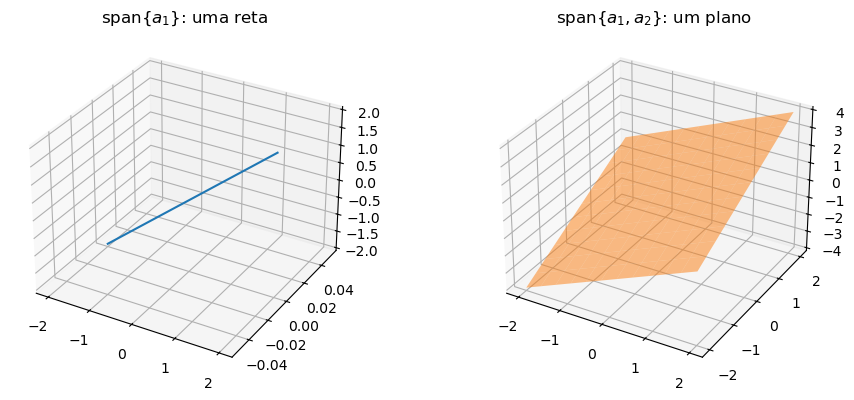

In [4]:
# span de 1 vetor (reta) e de 2 vetores LI (plano) em R^3.
a1 = np.array([1.0, 0.0, 1.0])
a2 = np.array([0.0, 1.0, 1.0])

t = np.linspace(-2, 2, 50)
reta = np.outer(t, a1)                  # pontos t*a1

g = np.linspace(-2, 2, 12)
A, B = np.meshgrid(g, g)
plano = A[..., None] * a1 + B[..., None] * a2   # alpha*a1 + beta*a2

fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot(*reta.T, color="tab:blue")
ax1.set_title(r"span$\{a_1\}$: uma reta")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(plano[..., 0], plano[..., 1], plano[..., 2], alpha=0.5, color="tab:orange")
ax2.set_title(r"span$\{a_1, a_2\}$: um plano")
plt.tight_layout(); plt.show()

## 3. Independência linear

Os vetores são **independentes** quando a única combinação que dá o vetor zero é a trivial.
Numericamente: monte a matriz com os vetores nas colunas e olhe o **posto**. Posto = número de
colunas $\Rightarrow$ independentes. **Exemplo 2**: $\mathbf{v}_2=2\mathbf{v}_1$ (dependentes) e
$\mathbf{e}_1,\mathbf{e}_2$ (independentes).

In [5]:
# Exemplo 2: dependência vs independência via posto.
v1 = np.array([1.0, 2.0])
v2 = np.array([2.0, 4.0])    # = 2*v1  -> dependentes
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])    # independentes

print("posto[v1 v2] =", np.linalg.matrix_rank(np.column_stack([v1, v2])), "(de 2 colunas -> dependentes)")
print("posto[e1 e2] =", np.linalg.matrix_rank(np.column_stack([e1, e2])), "(de 2 colunas -> independentes)")
print("2*v1 - v2 =", 2 * v1 - v2, " (relação não trivial que dá zero)")

posto[v1 v2] = 1 (de 2 colunas -> dependentes)
posto[e1 e2] = 2 (de 2 colunas -> independentes)
2*v1 - v2 = [0. 0.]  (relação não trivial que dá zero)


## 4. Matriz: leitura por colunas e por linhas

A mesma matriz $A\in\mathbb{R}^{m\times n}$ pode ser lida por **colunas** ($\mathbf{a}_j\in
\mathbb{R}^m$) ou por **linhas** ($\mathbf{r}_i\in\mathbb{R}^n$). A leitura por colunas é a mais
útil para posto, espaço coluna e espaço nulo. Em dados, cada coluna pode ser um *snapshot* de um
campo físico discretizado — leitura que reaparecerá quando organizarmos dados em matrizes mais
adiante no curso.

In [6]:
# Uma matriz lida por colunas e por linhas.
A = np.array([[1.0, 2.0, 0.0],
              [-1.0, 1.0, 3.0]])
print("A =\n", A)

print("\nColunas (cada uma em R^2):")
for j in range(A.shape[1]):
    print(f"  a_{j+1} = {A[:, j]}")

print("\nLinhas (cada uma em R^3):")
for i in range(A.shape[0]):
    print(f"  r_{i+1} = {A[i, :]}")

A =
 [[ 1.  2.  0.]
 [-1.  1.  3.]]

Colunas (cada uma em R^2):
  a_1 = [ 1. -1.]
  a_2 = [2. 1.]
  a_3 = [0. 3.]

Linhas (cada uma em R^3):
  r_1 = [1. 2. 0.]
  r_2 = [-1.  1.  3.]


## 5. Multiplicação matriz-vetor em três visões

Para $A\in\mathbb{R}^{m\times n}$ e $\mathbf{x}\in\mathbb{R}^n$:

1. **linha por coluna:** $y_i=\mathbf{r}_i^T\mathbf{x}$;
2. **combinação das colunas:** $A\mathbf{x}=\sum_j x_j\,\mathbf{a}_j$ (identidade central);
3. **transformação linear:** $T(\mathbf{x})=A\mathbf{x}$.

**Exemplo 3**: as três visões coincidem em $(3,4,-3)^T$.

In [7]:
# Exemplo 3: três visões da multiplicação matriz-vetor.
A = np.array([[1.0, -1.0],
              [2.0,  0.0],
              [0.0,  3.0]])
x = np.array([2.0, -1.0])

y1 = np.array([A[i, :] @ x for i in range(A.shape[0])])     # linha por coluna
y2 = sum(x[j] * A[:, j] for j in range(A.shape[1]))         # combinação das colunas
y3 = A @ x                                                  # operador do numpy

print("y (linha x coluna)        =", y1)
print("y (combinação de colunas) =", y2)
print("y (A @ x)                 =", y3)
print("As três coincidem?", np.allclose(y1, y2) and np.allclose(y2, y3))

y (linha x coluna)        = [ 3.  4. -3.]
y (combinação de colunas) = [ 3.  4. -3.]
y (A @ x)                 = [ 3.  4. -3.]
As três coincidem? True


Como $A\mathbf{x}=\sum_j x_j\mathbf{a}_j$, **todo** vetor $A\mathbf{x}$ é uma combinação das
colunas de $A$ — ou seja, vive no espaço coluna (Seção 11).

## 6. A matriz como transformação linear

Multiplicar por uma matriz $2\times2$ **transforma** o plano: rotaciona, escala, cisalha ou
**colapsa** uma dimensão (quando $\det=0$, as colunas são dependentes e a área vira zero).
Aplicamos cada matriz ao **quadrado unitário**.

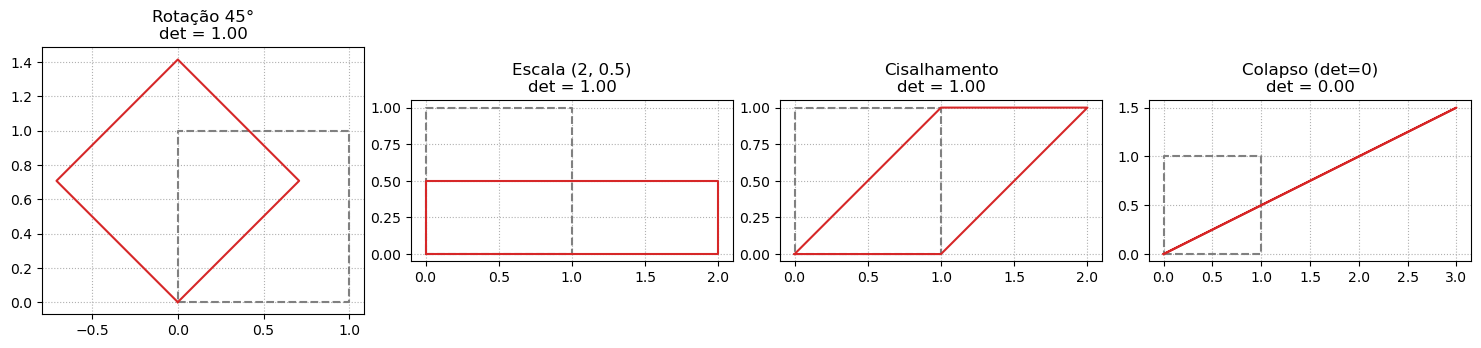

In [8]:
# Matrizes 2x2 como transformações do quadrado unitário.
quadrado = np.array([[0, 1, 1, 0, 0],
                     [0, 0, 1, 1, 0]], dtype=float)   # contorno fechado

transformacoes = {
    "Rotação 45°": np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)],
                              [np.sin(np.pi/4),  np.cos(np.pi/4)]]),
    "Escala (2, 0.5)": np.array([[2.0, 0.0], [0.0, 0.5]]),
    "Cisalhamento": np.array([[1.0, 1.0], [0.0, 1.0]]),
    "Colapso (det=0)": np.array([[1.0, 2.0], [0.5, 1.0]]),
}

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (titulo, M) in zip(axes, transformacoes.items()):
    img = M @ quadrado
    ax.plot(quadrado[0], quadrado[1], "gray", ls="--")   # original
    ax.plot(img[0], img[1], "tab:red")                   # transformado
    ax.set_title(f"{titulo}\ndet = {np.linalg.det(M):.2f}")
    ax.set_aspect("equal"); ax.grid(True, ls=":")
plt.tight_layout(); plt.show()

No último caso o quadrado vira um **segmento**: a transformação colapsou uma dimensão
($\det=0$), as colunas são dependentes e a matriz **não** é invertível.

## 7. Multiplicação matriz-matriz e não comutatividade

Se $A\in\mathbb{R}^{m\times n}$ e $B\in\mathbb{R}^{n\times p}$, então $AB\in\mathbb{R}^{m\times
p}$. A ordem importa: em geral $AB\ne BA$ e às vezes um dos produtos nem está definido. Vemos o
**Exemplo 4** (dimensões diferentes) e o **Exercício 3** (mesmas dimensões, produtos diferentes).

In [9]:
# Exemplo 4: AB e BA com tamanhos diferentes.
A = np.array([[1.0, 2.0, 0.0],
              [-1.0, 1.0, 3.0]])   # 2x3
B = np.array([[2.0, 1.0],
              [0.0, -1.0],
              [1.0, 4.0]])          # 3x2

print("AB tem forma", (A @ B).shape, "->\n", A @ B)   # referência: [[2, -1], [1, 10]]
print("\nBA tem forma", (B @ A).shape, "-> nem o tamanho coincide com AB")

AB tem forma (2, 2) ->
 [[ 2. -1.]
 [ 1. 10.]]

BA tem forma (3, 3) -> nem o tamanho coincide com AB


In [10]:
# Exercício 3: mesmas dimensões, mas AB != BA.
A2 = np.array([[1.0, 0.0], [2.0, 1.0]])
B2 = np.array([[3.0, 1.0], [-1.0, 2.0]])
print("A2 @ B2 =\n", A2 @ B2)
print("\nB2 @ A2 =\n", B2 @ A2)
print("\nAB == BA?", np.allclose(A2 @ B2, B2 @ A2))

A2 @ B2 =
 [[3. 1.]
 [5. 4.]]

B2 @ A2 =
 [[5. 1.]
 [3. 2.]]

AB == BA? False


## 8. Quarta visão: soma de produtos externos (posto um)

Lendo $A$ por colunas e $B$ por linhas, $AB=\sum_k\mathbf{a}_k\,\boldsymbol{\beta}_k^T$: uma soma
de matrizes de **posto um**. Cada $\mathbf{a}_k\boldsymbol{\beta}_k^T$ tem todas as colunas
múltiplas de $\mathbf{a}_k$. Toda matriz de posto $r$ é uma soma de $r$ matrizes de posto um —
ideia de **aproximação de baixo posto** que voltará mais adiante no curso.

In [11]:
# Um produto externo a b^T tem posto 1.
a = np.array([1.0, 2.0])
b = np.array([3.0, -1.0])
print("a b^T =\n", np.outer(a, b))
print("posto =", np.linalg.matrix_rank(np.outer(a, b)), "(colunas são múltiplas de a)")

a b^T =
 [[ 3. -1.]
 [ 6. -2.]]
posto = 1 (colunas são múltiplas de a)


In [12]:
# AB como soma de produtos externos coluna_k(A) x linha_k(B).
A = np.array([[1.0, 2.0, 0.0],
              [-1.0, 1.0, 3.0]])
B = np.array([[2.0, 1.0],
              [0.0, -1.0],
              [1.0, 4.0]])

parciais = []
acumulado = np.zeros((A.shape[0], B.shape[1]))
for k in range(A.shape[1]):
    acumulado = acumulado + np.outer(A[:, k], B[k, :])   # parcela de posto 1
    parciais.append(acumulado.copy())

print("Soma dos produtos externos =\n", acumulado)
print("Igual a A @ B?", np.allclose(acumulado, A @ B))

Soma dos produtos externos =
 [[ 2. -1.]
 [ 1. 10.]]
Igual a A @ B? True


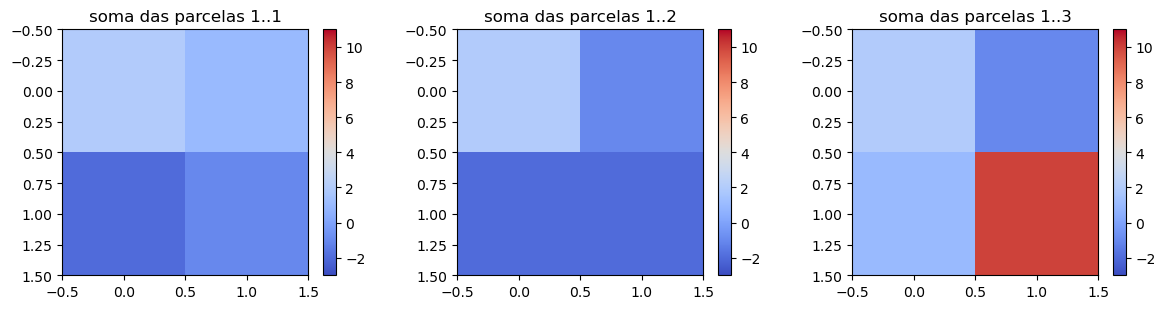

In [13]:
# Cada passo soma uma matriz de posto 1.
fig, axes = plt.subplots(1, len(parciais), figsize=(4 * len(parciais), 3.2))
for k, ax in enumerate(axes):
    im = ax.imshow(parciais[k], cmap="coolwarm", vmin=-3, vmax=11)
    ax.set_title(f"soma das parcelas 1..{k+1}")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 9. Transposta, produto interno e a matriz $A^TA$

Propriedades: $(A^T)^T=A$, $(A+B)^T=A^T+B^T$ e, com atenção à ordem, $(AB)^T=B^TA^T$. O **produto
interno** $\mathbf{x}^T\mathbf{y}=\sum_i x_iy_i$ mede alinhamento; zero significa **ortogonal**. A
matriz de Gram $A^TA$ guarda os produtos internos entre as colunas de $A$.

In [14]:
# Exercício 7: (AB)^T = B^T A^T.
A = np.array([[1.0, 2.0], [0.0, 1.0]])
B = np.array([[1.0, 0.0], [3.0, 1.0]])
print("(AB)^T =\n", (A @ B).T)
print("\nB^T A^T =\n", B.T @ A.T)
print("\nIguais?", np.allclose((A @ B).T, B.T @ A.T))

(AB)^T =
 [[7. 3.]
 [2. 1.]]

B^T A^T =
 [[7. 3.]
 [2. 1.]]

Iguais? True


In [15]:
# Produto interno, ortogonalidade e matriz de Gram.
x = np.array([1.0, 2.0, 2.0])
y = np.array([2.0, -1.0, 0.0])    # x.y = 0 -> ortogonais
print("x^T y =", x @ y, "-> ortogonais?", np.isclose(x @ y, 0.0))

A = np.array([[1.0, 0.0],
              [0.0, 1.0],
              [1.0, 1.0]])
print("\nA^T A (Gram) =\n", A.T @ A, "  (entrada (i,j) = coluna_i . coluna_j)")

x^T y = 0.0 -> ortogonais? True

A^T A (Gram) =
 [[2. 1.]
 [1. 2.]]   (entrada (i,j) = coluna_i . coluna_j)


## 10. Identidade, inversa e sistemas lineares

Se $A$ é invertível, $A\mathbf{x}=\mathbf{b}$ tem solução única $\mathbf{x}=A^{-1}\mathbf{b}$.
Para $2\times2$, a inversa existe sse $\det=ad-bc\ne0$. **Exemplo 5**: $\det=1$, solução
$(-1,3)^T$. Na prática **não** se inverte a matriz para resolver: usa-se um solver estável
(`np.linalg.solve`).

In [16]:
# Exemplo 5: sistema 2x2 via inversa e via solver.
A = np.array([[2.0, 1.0],
              [5.0, 3.0]])
b = np.array([1.0, 4.0])

print("det(A) =", round(np.linalg.det(A), 10))
print("A^{-1} =\n", np.linalg.inv(A))
print("x via inversa =", np.linalg.inv(A) @ b)     # didático
print("x via solve   =", np.linalg.solve(A, b))    # recomendado (referência: (-1, 3))

det(A) = 1.0
A^{-1} =
 [[ 3. -1.]
 [-5.  2.]]
x via inversa = [-1.  3.]
x via solve   = [-1.  3.]


## 11. Espaço coluna e solubilidade de $A\mathbf{x}=\mathbf{b}$

$\operatorname{Col}(A)=\{A\mathbf{x}\}=\operatorname{span}$ das colunas. O sistema
$A\mathbf{x}=\mathbf{b}$ tem solução **se e somente se** $\mathbf{b}\in\operatorname{Col}(A)$. No
**Exemplo 6**, $\operatorname{Col}(A)$ é o plano $b_3=b_1+b_2$: $(2,3,5)^T$ pertence (tem solução)
e $(2,3,4)^T$ não pertence (sem solução exata).

In [17]:
# Exemplo 6: Col(A) é o plano b3 = b1 + b2.
A = np.array([[1.0, 0.0],
              [0.0, 1.0],
              [1.0, 1.0]])

# b está em Col(A) se o resíduo de mínimos quadrados é ~ 0.
for b in [np.array([2.0, 3.0, 5.0]), np.array([2.0, 3.0, 4.0])]:
    x, *_ = np.linalg.lstsq(A, b, rcond=None)
    residuo = np.linalg.norm(A @ x - b)
    print(f"b = {b}: b3 == b1+b2? {np.isclose(b[2], b[0] + b[1])} | resíduo = {residuo:.2e}")

b = [2. 3. 5.]: b3 == b1+b2? True | resíduo = 1.66e-15
b = [2. 3. 4.]: b3 == b1+b2? False | resíduo = 5.77e-01


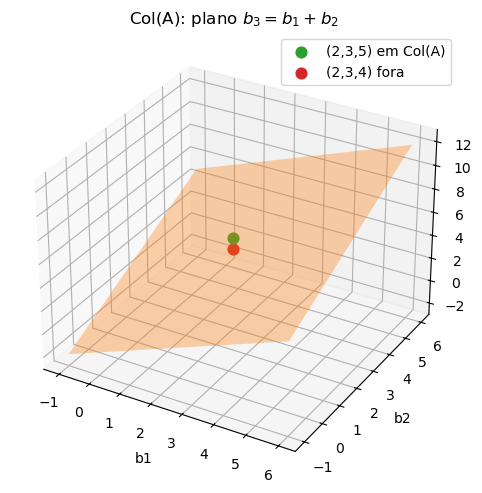

In [18]:
# Col(A) como plano em R^3, com um ponto dentro e um fora.
g = np.linspace(-1, 6, 12)
Aa, Bb = np.meshgrid(g, g)
plano = Aa[..., None] * A[:, 0] + Bb[..., None] * A[:, 1]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(plano[..., 0], plano[..., 1], plano[..., 2], alpha=0.35, color="tab:orange")
ax.scatter(2, 3, 5, color="tab:green", s=60, label="(2,3,5) em Col(A)")
ax.scatter(2, 3, 4, color="tab:red", s=60, label="(2,3,4) fora")
ax.set_xlabel("b1"); ax.set_ylabel("b2"); ax.set_zlabel("b3")
ax.set_title(r"Col(A): plano $b_3 = b_1 + b_2$"); ax.legend()
plt.tight_layout(); plt.show()

## 12. Espaço nulo

$\operatorname{Nul}(A)=\{\mathbf{x}:A\mathbf{x}=\mathbf{0}\}$ reúne as direções **anuladas** pela
matriz (ligadas à não unicidade em problemas inversos). No **Exemplo 7**,
$\operatorname{Nul}(A)=\operatorname{span}\{(1,-1,1)^T\}$.

In [ ]:
# Exemplo 7: espaço nulo resolvido como nas notas (substituição).
A = np.array([[1.0, 2.0, 1.0],
              [0.0, 1.0, 1.0],
              [1.0, 3.0, 2.0]])

# Resolvendo A x = 0 à mão: x2 = -x3 e x1 = x3, logo x = t * (1, -1, 1).
v = np.array([1.0, -1.0, 1.0])     # gera Nul(A)
print("Direção que gera Nul(A):", v)
print("A @ v =", A @ v, "-> é o vetor zero?", np.allclose(A @ v, 0.0))

## 13. Posto e teorema do núcleo e da imagem

O **posto** é a dimensão do espaço coluna (nº de colunas independentes). O **teorema do núcleo e
da imagem** (posto-nulidade) afirma:

$$\operatorname{rank}(A)+\dim(\operatorname{Nul} A)=n.$$

Verificamos para o **Exemplo 7** (coluna $a_2=a_1+a_3$) e o **Exemplo 8** (coluna $b_3=b_1+b_2$),
ambos com posto 2 em $\mathbb{R}^3$.

In [ ]:
# Posto e teorema posto-nulidade: rank(A) + dim Nul(A) = n.
A7 = np.array([[1.0, 2.0, 1.0],
               [0.0, 1.0, 1.0],
               [1.0, 3.0, 2.0]])   # a2 = a1 + a3  -> coluna dependente
B8 = np.array([[1.0, 0.0, 1.0],
               [0.0, 1.0, 1.0],
               [0.0, 1.0, 1.0]])   # b3 = b1 + b2  -> coluna dependente

# Base do núcleo obtida à mão pela relação de dependência entre as colunas.
nul7 = [np.array([1.0, -1.0, 1.0])]   # a1 - a2 + a3 = 0
nul8 = [np.array([1.0, 1.0, -1.0])]   # b1 + b2 - b3 = 0

for nome, M, base_nul in [("Exemplo 7", A7, nul7), ("Exemplo 8", B8, nul8)]:
    n = M.shape[1]
    posto = np.linalg.matrix_rank(M)
    dim_nul = len(base_nul)               # nº de vetores na base do núcleo
    anula = all(np.allclose(M @ x, 0.0) for x in base_nul)
    print(f"{nome}: posto = {posto}, dim Nul = {dim_nul}, n = {n},",
          f"posto + dim Nul = {posto + dim_nul} (base anula M? {anula})")

## Síntese da aula

- O **espaço coluna** descreve o que a matriz *produz* na saída; o **espaço nulo**, o que ela
  *anula* na entrada; o **posto** conta as direções independentes que sobrevivem.
- O **teorema do núcleo e da imagem** $\operatorname{rank}(A)+\dim(\operatorname{Nul} A)=n$ diz
  que o que é preservado e o que é perdido somam a dimensão de entrada.
- Ler $A\mathbf{x}$ como **combinação de colunas** e $AB$ como **soma de produtos externos de
  posto um** já antecipa a ideia de representar dados por poucas direções dominantes.

## Limitações a discutir

- Posto e independência calculados numericamente dependem de uma **tolerância**; ruído e
  arredondamento podem alterar o posto observado.
- Calcular $A^{-1}$ explicitamente é instável e caro; para resolver $A\mathbf{x}=\mathbf{b}$,
  prefira `np.linalg.solve`.
- O critério do determinante usado aqui vale para o caso $2\times2$; não o tome como fórmula
  geral para $n$ grande.

## Experimentos sugeridos

1. Mude $\mathbf{x}$ no Exemplo 3 e confirme que as três visões continuam coincidindo.
2. Construa uma matriz $3\times3$ de **posto 1** e observe $\operatorname{rank}$,
   $\dim\operatorname{Nul}$ e a reta/plano de $\operatorname{Col}$.
3. Perturbe uma coluna dependente por $10^{-8}$ e veja o **posto numérico** mudar.
4. Troque $\mathbf{b}$ no Exemplo 6 entre dentro/fora de $\operatorname{Col}(A)$ e acompanhe o
   resíduo de `lstsq`.

*Próxima aula (Aula 3): autovalores, autovetores, decomposição espectral, matrizes ortogonais e
normas.*